## Two Equivalent Definitions Strongly Regular Graphs
- Combinatorial Definition:
    1. for integer $k$, has $k$ number of neighbors
    2. for integer $λ$ as common neighbors, if vertices $x$ & $y$ share an edge, they also share the same number of mutual neighbors, vertices $z$
    3. for vertices $x$ & $y$ which are not neighbors (that don't share an edge) have the same number $μ$ of vertices $z$ as neighbors
- Spectral Definition:
    - A strongly regular graph is a finite regular graph with exactly 2 restricted eigenvalues
- These two definitions are proven to be equal by the $A^2$ identity, which uses the parameters $k, λ, µ,$ where $A$ is the Adjacency matrix of a Strongly Regular Graph with the eigenvalue $k$
- The $A^2$ identity is therefore able to prove that A has 2 eigenvalues using the parameter $k, λ, µ$
    - $A^2 = λA + µ(J − I − A) + kI = (λ − µ)A + µJ + (k − µ)I$

# Importance of Strongly Regular Graphs in Combinatorics, Abstract Algebra, and Coding Theory

## I. SRG in Combinatorics

Strongly Regular Graphs are a fundamental aspect of study within combinatorics, a type of mathematics which deals with counting, arranging, and organizing objects, without the use of calculus or continuous math. Many well known strongly regular graphs are derived from combinatorial constructions like Latin Square Graphs.  

- Latin Squares are an $n$x$n$ grid where each number spans between 1 and $n$, with absolutely no repeating numbers in a row or column. Latin Square Graphs are then constructed from Latin Squares, where each cell in the grid becomes a vertex (also known as nodes) and the number of nodes an LSG has is found using $n^2$. Two nodes share an edge if they are in the same column, row, or if they are simply the same number regardless of which row or column.
  
- To find $k$, the number of neighbors a cell has in Latin Square graphs, $k = 3(n-1)$, this is because, in order for a cell to actually share an edge it must meet exactly one of the three requirements (row, column, or number). Since a cell, is neighbors with every other cell in its row it has $(n-1)$ neighbors in it's row, it also becomes neighbors with every other cell in it's column so another $(n-1)$, finally it is also neighbors with the same number that is repeated in every other column or row so another $(n-1)$. This totals to $k = (n-1) + (n-1) + (n-1)$, when simplified it is $k=3(n-1)$

- Every pair of vertices that shares an edge has n common neighbors, therefore $λ$ = $n$ common neighbors, this is the case as, the pair of nodes would share (n-2) common neighbors with the rest of the row. Then the first number in the pair that would be repeated in the column on the second number would be the next common neighbor (+1), and vice versa where the second number which is repeated in the column of the first number would the other common neighbor (+1). Therefore, $λ$ = $(n-2)+1+1$ = $n$

- Meanwhile, when looking at nodes that don't share an edge, they will always share a constant value of common neighbors as $μ$ = 6. This constant value of 6 does not depend on the size of the grid and instead stems from the criteria being met which are row, column and number. This is because, when you have 2 cells that are not neighbors, the first cell has 2 common neighbors from the cell that also shares a row with the second cell and the number from cell 2 being repeated in the column of cell 1. Then the second cell has 2 common neighbors from the cell that shares a column with the first cell and the number of the first cell being repeated in the column of cell 2. Lastly, there are two more common neighbors from the same number in cell 1 and 2 being repeated in the other columns. In this way $μ$ will always be six regardless of the size of the Latin Square Graph.

Latin Square Graphs satisfy all the requirements in the definition of Strongly Regular Graphs, as each node has the same $k$ number of neighbors, each pair has the same $λ$ common neighbors when they share an edge, and has the same $μ$ common neighbors if they don't share an edge regardless of which cells are chosen.

In [6]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

Latin Square with 3x3 grid

[1, 2, 3]
[2, 3, 1]
[3, 1, 2]


Nodes of the Graph: 
 [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3), (3, 1), (3, 2), (3, 3)]


The number of edges the Latin Square Graph has:  27


The degrees or number of neighbors the Latin Square Graph has: 
 {(1, 1): 6, (1, 2): 6, (1, 3): 6, (2, 1): 6, (2, 2): 6, (2, 3): 6, (3, 1): 6, (3, 2): 6, (3, 3): 6}
calculated value: λ = {3}, predicted value: λ = n = 3
calculated value: μ = {6}, predicted μ = 6


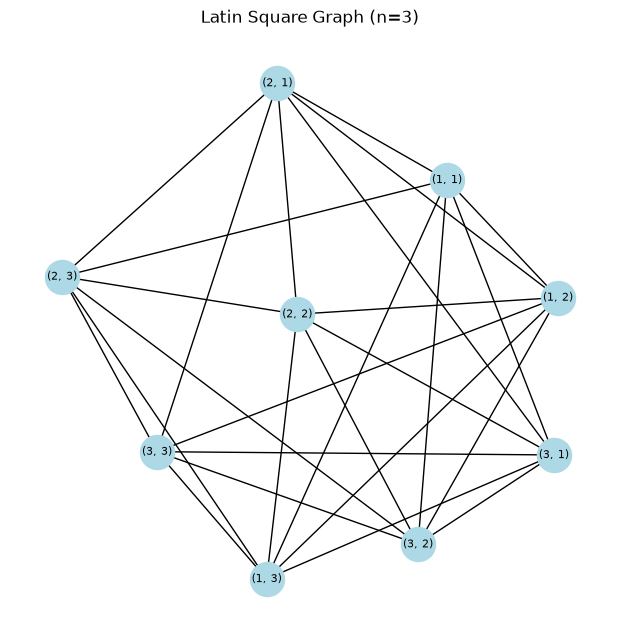

In [28]:
# First Create Initial Matrix Outline
n = 3
mat = []
node_rlist = []
node_clist = []
for i in range(n):
    mat.append([0] *n)
#print(*mat, sep="\n")

# Start to insert values
for r in range(n):
    for c in range(n):
        mat[r][c] = ((r+c) % n)+1
        node_rlist.append(r+1)
        node_clist.append(c+1)

node_list = list(zip(node_rlist, node_clist))
print("Latin Square with %dx%d grid\n" % (n,n))
print(*mat, sep="\n")
print("\n")
print("Nodes of the Graph: \n", node_list)
print("\n")

LSG = nx.Graph()
LSG.add_nodes_from(node_list)

# Create 2 different tuples of the same node list to compare and make sure that the graph is built to LSG specifications
pc = 0
for i in range(len(node_list)):
    for j in range(i+1, len(node_list)):
        node1 = node_list[i]
        node2 = node_list[j]
        pc+=1

# check for same row, column or number which are conditions to identify neighbors (k degree
        if node1[0] == node2[0] or node1[1] == node2[1] or mat[node1[0]-1][node1[1]-1] == mat[node2[0]-1][node2[1]-1]:
           # print("connected")
            LSG.add_edge(node1, node2)
        #print(f" pair count: {pc}, node1: {node1} & node2: {node2} \n")

        
            


print("The number of edges the Latin Square Graph has: ", LSG.number_of_edges())
print("\n")
print("The degrees or number of neighbors the Latin Square Graph has: \n", dict(LSG.degree()))

# a new loop to check for common and uncommon neighbors
lambda_list = set()  #set of common neighbors
mu_list = set()      # set of uncommon neighbors

pc = 0
for i in range(len(node_list)):
    for j in range(i+1, len(node_list)):
        node1 = node_list[i]
        node2 = node_list[j]
        pc+=1

        common_neighbors = set(LSG[node1]) & set(LSG[node2])
        count = len(common_neighbors)


        if LSG.has_edge(node1, node2):
            lambda_list.add(count)
        else:
            mu_list.add(count)

print(f"calculated value: λ = {lambda_list}, predicted value: λ = n = {n}")
print(f"calculated value: μ = {mu_list}, predicted μ = 6")

#draw graph
pos = nx.spring_layout(LSG, seed=42)
plt.figure(figsize=(6,6))
nx.draw(LSG, pos, with_labels=True, node_color='lightblue', node_size=600, font_size=8)
plt.title(f"Latin Square Graph (n={n})")
plt.show()

## Strongly Regular Graphs in Abstract Algebra 

The use of strongly regular graphs in abstract algebra is primarily seen in group theory, which is also known as the study of symmetry. In comparison to proving how Strongly Regular graphs are prevalent in combinatorics where the criteria were proven through hand counting, in group theory λ, and μ remain constant through the use of pure symmetry.

- In abstract algebra, a permutation group is a group with G, paied with a function that reorganizes the elemnts of a set X. Where every part of G plays a role in reorganizing the pieces of X
- The group G is transitive, if any part of X can be mapped to any other, so if starting at one element you can still reach any other part
- A group is of rank 3 when G has 3 orbits, where the pairs split into D, E and F, where D is x=y. Meanwhile if E and F are symmetric then they have 2 different graphs, (X, E) which refers to an adjacent or edge, and other one which is (X,F) which refers to the complement or non-adjacent.
- Automorphism is where vertices are relabeled or reorganized to ensure that the adjacency relationship is preserved, this causes every edge and non edge to be shuffled without disturbing their characteristics
- Since G is transitive, for adjacent pairs, it allows for any adjacent pair of vertices to be mapped out by automorphisms to any other adjacent pair. In this way automorphism can retain the exact graph structure, while simultaneously preserving the number of common neighbors. This causes every adjacent pair to share the same constant λ, and similarly every non-adjacent pair must share the same constant μ.

Therefore, the amount of common neighbors of 2 vertices relies only on whether they are equal, adjacent, or nonadjacent, and does not depend on the chosen vertices.

## Strongly Regular Graphs in Coding Theory

In coding theory Strongly Regular Graphs mainly show up in the Hoffman Bound which is derived from Delsarte. It works to create a strict upper limit on the size of a clique, which is a set of vertices that are all mutually connected to one another, in a strongly regular graph($|D| ≤ 1 + k/(-s)$) and is based on the graph's degree $k$ and it's smallest eigenvalue $s$. Meaning, the subset of a strongly regular graph can never go over the size limit found based on the graph's spectrum, regardless of how the graph is otherwise structured. This connection to coding theory comes from the Hoffman bound which is a special version of the Delsarte/Linear programming bound which limits the maximum possible size of an error correcting-code.

In [32]:
# build petersen graph
c = nx.petersen_graph()
a = nx.to_numpy_array(c) # turn grpah into numpy array in order to list the eigenvalues of the graph
eigenvalues = np.linalg.eigvalsh(a)
print(f"Eigenvalues: {eigenvalues}\n")

#find k the largest value
k = np.max(eigenvalues)
print(f"largest eigenvalue k: {k}\n")

# find s the smallest eigenvalue
s = np.min(eigenvalues)
print(f"smallest eigenvalue s: {s}\n")

#calculate Hoffman Bound 
D = 1+(k/-s)
print(f"Hoffman Bound on clique size: {D}\n")

# find actual max clique size
b = list(nx.find_cliques(c))
print(f"Maximal Cliques found: {b}\n")


largest_size = max(len(clique) for clique in b)
print(f"Actual largest clique size: {largest_size}")

Eigenvalues: [-2. -2. -2. -2.  1.  1.  1.  1.  1.  3.]

largest eigenvalue k: 3.0

smallest eigenvalue s: -2.0000000000000004

Hoffman Bound on clique size: 2.5

Maximal Cliques found: [[0, 1], [0, 4], [0, 5], [2, 1], [2, 3], [2, 7], [3, 8], [3, 4], [6, 8], [6, 1], [6, 9], [7, 9], [7, 5], [8, 5], [9, 4]]

Actual largest clique size: 2


- Using the Petersen graph to apply the Hoffman Bound, it is found that k = 3 and s ≈ -2, leading to a bound of $|D| ≤ 2.5$, but the size of a clique must be a whole number, which entails that the cliques of the Petersen graph must have no more than 2 vertices. This is found to be true as the actual size of the largest clique has exactly 2 vertices, which illustrates our theoretical prediction, showing that the eigenvalue rule belonging to strongly regular graphs restricts the structure that can exist in it.

# Famous Strongly Regular Graphs

## I. Petersen Graph

The Petersen Graph was built by a Danish mathematician named Julius Petersen. He specifically constructed this graph to refute a mathematical conjecture that was widely known. It claimed that any connected, bridgeless cubic graph could always be edge colored with just 3 colors. So Petersen went out of his way to create a graph that fulfilled all the conditions, it was connected, bridgeless and cubic, but because of it's specific structure it could not be edge-colored with 3 colors. The Petersen graph is also the unique strongly regular graph with parameters (v, k, λ, µ) = (10, 3, 0, 1), where no other graph has the same set of parameters. It is also a complement of the triangular graph T(5) which happens to be a specific case of another well known Strongly Regular graph, the Johnson graph.

Edges in Petersen Graph: 15

Nodes in Line Graph: 15

distinct colors: 4



Text(0.5, 1.0, 'Edge-Colored Petersen Graph')

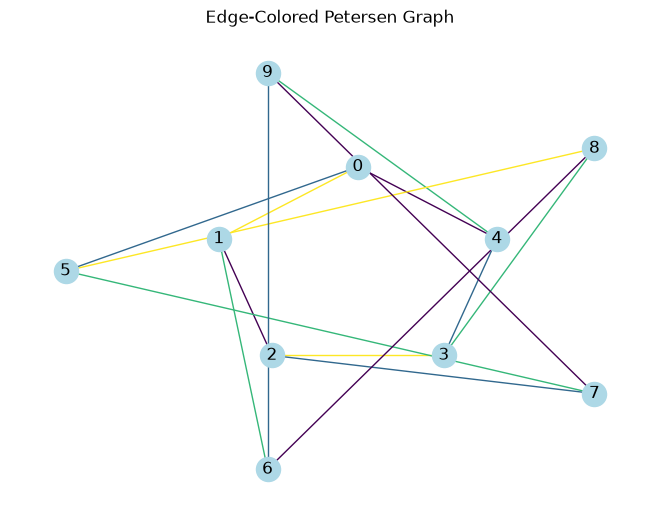

In [52]:
g = nx.petersen_graph() #Petersen Graph
l = nx.line_graph(g) #turns above petersen graph into a line graph

print(f"Edges in Petersen Graph: {g.number_of_edges()}\n")
print(f"Nodes in Line Graph: {l.number_of_nodes()}\n")

lc = nx.coloring.greedy_color(l)
#print(lc)

colors = set(lc.values())
print(f"distinct colors: {len(colors)}\n")

edgelist = list(lc.keys())
for i in range(len(edgelist)):
    for j in range(i+1, len(edgelist)):
        edge1 = edgelist[i]
        edge2 = edgelist[j]
        if edge1[0] in edge2 or edge1[1] in edge2:
           if lc[edge1] == lc[edge2]:
               print(f"Conflict between {edge1} & {edge2}")

edge_colors = []
for u, v in g.edges():
    edge_colors.append(lc.get((u,v)))
    

pos = nx.shell_layout(g, nlist=[list(range(5)), list(range(5, 10))])
nx.draw(g, pos, with_labels=True, edge_color=edge_colors, node_color='lightblue')
plt.title(f"Edge-Colored Petersen Graph")

- To go through this historical conjecture, the edge coloring method was followed using a greedy algorithm, by turning a Petersen graph into a Line graph, in order to compare the number of edges and nodes respectively. To confirm that Petersen graphs can't be edge colored with 3 colors, the greedy algorithm required 4 colors for all 15 edges. Although the algorithm doesn't prove that using 3 colors is completely impossible, the outcome is sufficient enough to align with established theory that the chromatic index is 4. This follows Julius Petersen's claim of 4 colors instead of 3, as a strong counterexample.

## II. Johnson Graph

Johnson graphs, as previously mentioned are another well known case of Strongly Regular Graphs. It is made up of a set $Ω$ and an integer $d$ $≥$ 0, making the Johnson graph $J$($Ω$, $d$), and its vertices are all possible $d$-element subsets of $Ω$. If 2 subsets of a Johnson graph share $d-1$ elements, between the two subsets, meaning that they now share an edge. When $d=2$ it is a specific case of the Johnson graph known as the triangular graph $T(m)$. Meanwhile, the complement of the triangular graph $T(5)$ is the Petersen graph.


## III. Hamming Graph

Similar to Johnson graphs, Hamming graphs are also composed of a set $Ω$ and an integer $d$ $≥$ 0, but unlike Johnson graphs, which use subsets, the Hamming graph uses tuples $H(d,Ω)$. Here the vertices of a Hamming graph are all possible $d$-tuples of the set $Ω$, and if two of these tuples differ by exactly one position, then they are adjacent and this is known as Hamming distance 1. A special case of the Hamming graph occurs when $H(2,q)$ as this structure is relatively close to the build of Latin Square Graphs, without the same number rule. This specific $H(2,q)$ is known as a Lattice graph $L_{2}(q)$ or the $q×q$ grid, a concept which is very similar to the one introduced at the beginning.

## Citations
1. Brouwer, A. E. B. E., & Maldeghem, H. V. (n.d.). Strongly regular graphs Andries E. Brouwer Hendrik van Maldeghem. https://homepages.cwi.nl/~aeb/math/srg/rk3/srgw.pdf
2. Spielman, D. A. (n.d.). Spectral graph theory lecture 23 strongly regular graphs, part 1. https://www.cs.yale.edu/homes/spielman/561/2009/lect23-09.pdf 